Best Parameters: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 50}

Cross Validation Scores: [0.6375 0.7125 0.7    0.6875 0.6625]
Average CV Score: 0.6799999999999999

Optimized Model Accuracy: 0.67

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.68      0.97      0.80        69

    accuracy                           0.67       100
   macro avg       0.34      0.49      0.40       100
weighted avg       0.47      0.67      0.55       100



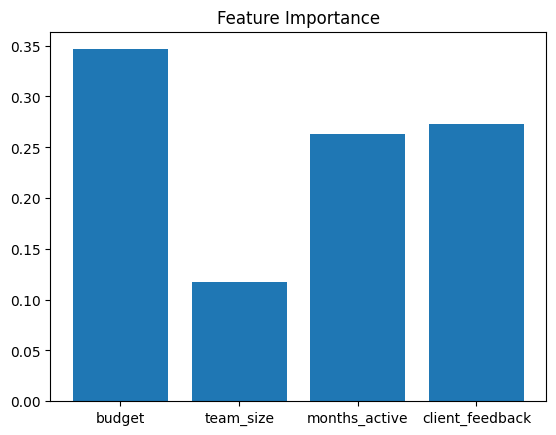

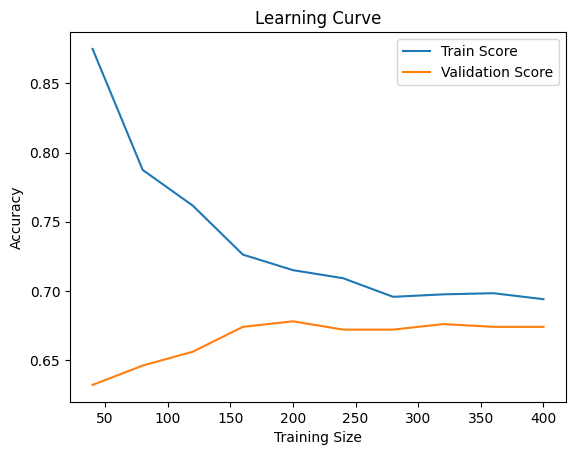


BEFORE: 0.85
AFTER : 0.67

Train Accuracy: 0.7025
Test Accuracy : 0.67
Model is well balanced


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# -----------------------------
# 1. DATA (same as Task 5)
# -----------------------------
np.random.seed(42)
n_samples = 500

data = {
    'budget': np.random.randint(5000, 50000, n_samples),
    'team_size': np.random.randint(2, 15, n_samples),
    'months_active': np.random.randint(1, 12, n_samples),
    'client_feedback': np.random.uniform(1.0, 5.0, n_samples),
    'project_status': np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7])
}

df = pd.DataFrame(data)

X = df.drop('project_status', axis=1)
y = df['project_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2. BASE MODEL
# -----------------------------
rf = RandomForestClassifier(random_state=42)

# -----------------------------
# 3. GRID SEARCH (Hyperparameter tuning)
# -----------------------------
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# -----------------------------
# 4. CROSS VALIDATION
# -----------------------------
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

# -----------------------------
# 5. TRAIN FINAL MODEL
# -----------------------------
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc_after = accuracy_score(y_test, y_pred)

print("\nOptimized Model Accuracy:", acc_after)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 6. FEATURE IMPORTANCE
# -----------------------------
importances = best_model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

# -----------------------------
# 7. LEARNING CURVE
# -----------------------------
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# 8. BEFORE vs AFTER
# -----------------------------
before_accuracy = 0.85  # apne Task 5 ka best accuracy yahan dalna

print("\n====================")
print("BEFORE:", before_accuracy)
print("AFTER :", acc_after)
print("====================")

# -----------------------------
# 9. OVERFITTING CHECK (simple logic)
# -----------------------------
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

if train_acc - test_acc > 0.1:
    print("Warning: Overfitting detected")
else:
    print("Model is well balanced")